# WFI2033 HMC Covariance Check (ss=2)

This notebook reads `Herculens/WFI2033_psf_correct_all_ss=2.nc` and computes the covariance/correlation matrix using the same HMC parameter names and dense-mass grouping used in `WFI2033_model_to_hmc.py`.


In [1]:
import os
os.environ.setdefault('HDF5_USE_FILE_LOCKING', 'FALSE')

from pathlib import Path
import numpy as np
import arviz as az
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.dpi'] = 120


/home/skylee/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/skylee/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
NC_PATH = Path('/mnt/d/lensing/Herculens/WFI2033_psf_correct_all_ss=2.nc')
assert NC_PATH.exists(), f'File not found: {NC_PATH}'

idata = az.from_netcdf(NC_PATH)
post = idata.posterior
print('Loaded:', NC_PATH)
print('chains, draws =', int(post.sizes['chain']), int(post.sizes['draw']))

# Use exactly the same dense_mass names as in WFI2033_model_to_hmc.py
DENSE_MASS_GROUPS = [
    ['n_source_grid', 'rho_source_grid', 'sigma_source_grid', 'A_lens', 'sigma_lens', 'e_lens', 'center_lens'],
    ['center_1', 'theta_E_1', 'theta_E_g1', 'theta_E_g2', 'e_1', 'gamma_1', 'gamma_sheer_1'],
    ['ra_ps', 'dec_ps', 'log10_amp_ps'],
]

for gi, g in enumerate(DENSE_MASS_GROUPS, start=1):
    missing = [v for v in g if v not in post]
    print(f'group {gi} vars:', g)
    if missing:
        raise KeyError(f'Missing vars in posterior for group {gi}: {missing}')


Loaded: /mnt/d/lensing/Herculens/WFI2033_psf_correct_all_ss=2.nc
chains, draws = 4 8000
group 1 vars: ['n_source_grid', 'rho_source_grid', 'sigma_source_grid', 'A_lens', 'sigma_lens', 'e_lens', 'center_lens']
group 2 vars: ['center_1', 'theta_E_1', 'theta_E_g1', 'theta_E_g2', 'e_1', 'gamma_1', 'gamma_sheer_1']
group 3 vars: ['ra_ps', 'dec_ps', 'log10_amp_ps']


In [3]:
def flatten_var(post_ds, var_name):
    # shape -> (samples, ndim_of_var)
    arr = post_ds[var_name].stack(sample=('chain', 'draw')).transpose('sample', ...)
    a = np.asarray(arr.values)
    return a.reshape(a.shape[0], -1)

X_list = []
labels = []
block_id = []

for gi, g in enumerate(DENSE_MASS_GROUPS, start=1):
    for v in g:
        flat = flatten_var(post, v)
        X_list.append(flat)
        for j in range(flat.shape[1]):
            labels.append(f'{v}[{j}]')
            block_id.append(gi)

X = np.concatenate(X_list, axis=1)  # (n_samples, n_params)
print('X shape =', X.shape)

cov = np.cov(X, rowvar=False)
corr = np.corrcoef(X, rowvar=False)

print('cov shape =', cov.shape)
print('corr shape =', corr.shape)


X shape = (32000, 37)
cov shape = (37, 37)
corr shape = (37, 37)


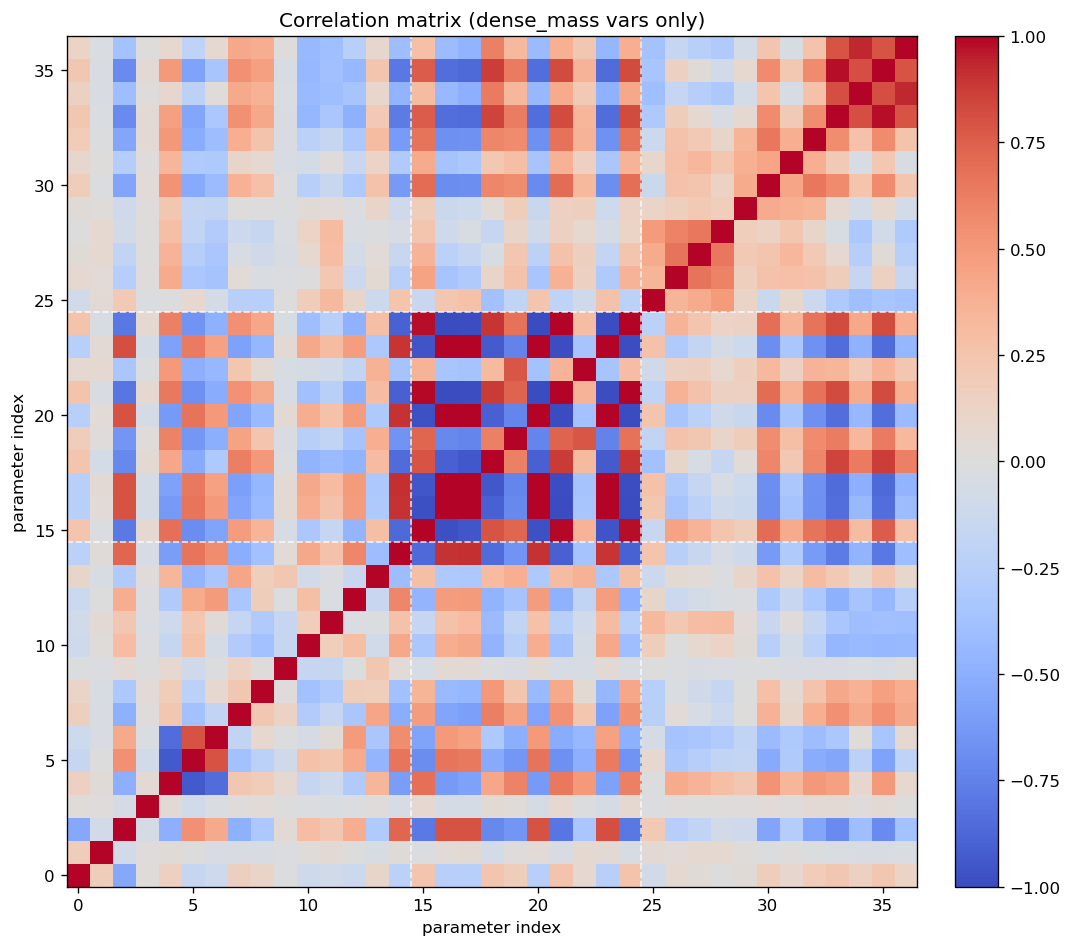

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(9, 8))

im = ax.imshow(corr, origin='lower', cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Correlation matrix (dense_mass vars only)')
ax.set_xlabel('parameter index')
ax.set_ylabel('parameter index')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# draw block boundaries
block_sizes = []
for gi in [1, 2, 3]:
    block_sizes.append(sum(1 for b in block_id if b == gi))

cuts = np.cumsum(block_sizes)
for c in cuts[:-1]:
    ax.axvline(c - 0.5, color='white', ls='--', lw=1.0, alpha=0.8)
    ax.axhline(c - 0.5, color='white', ls='--', lw=1.0, alpha=0.8)

plt.tight_layout()
plt.show()


In [5]:
param_index_table = pd.DataFrame({
    'index': np.arange(len(labels), dtype=int),
    'parameter': labels,
    'block': np.array(block_id, dtype=int),
})

print(f'Total parameters in matrix: {len(param_index_table)}')
param_index_table


Total parameters in matrix: 37


,index,parameter,block
0,0,n_source_grid[0],1
1,1,rho_source_grid[0],1
2,2,sigma_source_grid[0],1
3,3,A_lens[0],1
4,4,A_lens[1],1
5,5,sigma_lens[0],1
6,6,sigma_lens[1],1
7,7,e_lens[0],1
8,8,e_lens[1],1
9,9,e_lens[2],1


In [6]:
abs_corr = np.abs(corr)
np.fill_diagonal(abs_corr, np.nan)

idx_by_block = {
    1: np.where(np.array(block_id) == 1)[0],
    2: np.where(np.array(block_id) == 2)[0],
    3: np.where(np.array(block_id) == 3)[0],
}

def block_stats(idx_a, idx_b):
    sub = abs_corr[np.ix_(idx_a, idx_b)]
    vals = sub[np.isfinite(sub)]
    return float(np.nanmedian(vals)), float(np.nanmean(vals)), float(np.nanmax(vals))

print('Within-block |corr| stats (median, mean, max):')
for b in [1, 2, 3]:
    med, mean, mx = block_stats(idx_by_block[b], idx_by_block[b])
    print(f'  block {b}: median={med:.3f}, mean={mean:.3f}, max={mx:.3f}')

print('\nCross-block |corr| stats (median, mean, max):')
pairs = [(1, 2), (1, 3), (2, 3)]
for a, b in pairs:
    med, mean, mx = block_stats(idx_by_block[a], idx_by_block[b])
    print(f'  block {a}-{b}: median={med:.3f}, mean={mean:.3f}, max={mx:.3f}')

cross_entries = []
for a, b in pairs:
    ia = idx_by_block[a]
    ib = idx_by_block[b]
    sub = abs_corr[np.ix_(ia, ib)]
    for i in range(sub.shape[0]):
        for j in range(sub.shape[1]):
            val = sub[i, j]
            if np.isfinite(val):
                cross_entries.append((float(val), labels[ia[i]], labels[ib[j]], a, b))

cross_entries.sort(key=lambda x: x[0], reverse=True)
print('\nTop 15 cross-block |corr| pairs:')
for val, la, lb, a, b in cross_entries[:15]:
    print(f'  |corr|={val:.3f}  ({a}-{b})  {la}  <->  {lb}')


Within-block |corr| stats (median, mean, max):
  block 1: median=0.156, mean=0.215, max=0.930
  block 2: median=0.923, mean=0.803, max=0.999
  block 3: median=0.259, mean=0.323, max=0.979

Cross-block |corr| stats (median, mean, max):
  block 1-2: median=0.401, mean=0.389, max=0.907
  block 1-3: median=0.176, mean=0.212, max=0.795
  block 2-3: median=0.354, mean=0.406, max=0.869

Top 15 cross-block |corr| pairs:
  |corr|=0.907  (1-2)  center_lens[3]  <->  theta_E_1[0]
  |corr|=0.905  (1-2)  center_lens[3]  <->  e_1[0]
  |corr|=0.903  (1-2)  center_lens[3]  <->  center_1[1]
  |corr|=0.899  (1-2)  center_lens[3]  <->  e_1[1]
  |corr|=0.897  (1-2)  center_lens[3]  <->  gamma_sheer_1[1]
  |corr|=0.897  (1-2)  center_lens[3]  <->  gamma_sheer_1[0]
  |corr|=0.869  (2-3)  theta_E_g1[0]  <->  log10_amp_ps[2]
  |corr|=0.864  (1-2)  center_lens[3]  <->  center_1[0]
  |corr|=0.861  (2-3)  theta_E_1[0]  <->  log10_amp_ps[2]
  |corr|=0.858  (1-2)  center_lens[3]  <->  theta_E_g1[0]
  |corr|=0.855  

In [7]:
# Simple rule-of-thumb verdict for current dense_mass setup
# If most cross-block correlations are moderate/low (e.g. median <~ 0.2), block split is usually reasonable.

med12 = np.nanmedian(abs_corr[np.ix_(idx_by_block[1], idx_by_block[2])])
med13 = np.nanmedian(abs_corr[np.ix_(idx_by_block[1], idx_by_block[3])])
med23 = np.nanmedian(abs_corr[np.ix_(idx_by_block[2], idx_by_block[3])])

print('Median cross-block |corr|:', {'1-2': float(med12), '1-3': float(med13), '2-3': float(med23)})

if max(med12, med13, med23) < 0.2:
    print('Verdict: current mass-matrix block setting looks reasonable.')
elif max(med12, med13, med23) < 0.35:
    print('Verdict: current setting is usable; some cross-block coupling exists.')
else:
    print('Verdict: strong cross-block coupling; consider regrouping dense_mass.')


Median cross-block |corr|: {'1-2': 0.40146396855429933, '1-3': 0.17622332415417888, '2-3': 0.3543773438694934}
Verdict: strong cross-block coupling; consider regrouping dense_mass.
